# Approach 4 —— Online Price-Posting Market

**作者**：金娴  
**学号**：122020366  

## 1. 问题建模

### 1.1 在线 Fisher 市场问题

本实验研究**在线价格发布市场（Price-Posting Market）中的资源分配问题**。
与拍卖市场不同，**决策者（卖方）只发布每种商品的价格向量 $p \in \mathbb{R}^m$**，
买家在给定价格下自主做出购买决策。

市场中共有 $m = 10$ 种商品，每种商品总供给量 $\bar{s}_i = 1000$。
共有 $n = 10000$ 个买家**依次到来**，每个买家 $j$ 携带：

- **预算** $w_j > 0$：买家的总消费上限
- **效用向量** $u_j = (u_{1j}, \ldots, u_{mj}) \ge 0$：买家对每种商品的单位效用

买家在给定价格 $p$ 下求解**线性效用最大化**问题：

$$\max_{x_j \ge 0}\ \sum_{i=1}^m u_{ij} x_{ij} \quad \text{s.t.} \quad p^\top x_j \le w_j$$

**线性效用下的最优策略（Bang-per-Buck）**：买家将全部预算投入性价比最高的商品：

$$i^*_j = \arg\max_i \frac{u_{ij}}{p_i}, \qquad
x_{i^*_j,\,j} = \frac{w_j}{p_{i^*_j}}, \qquad x_{ij} = 0 \;\; (i \ne i^*_j)$$

决策者的目标是找到**市场均衡价格**，使市场出清并最大化总社会福利（Eisenberg-Gale 规划）：

$$\max_{x \ge 0}\ \sum_{j=1}^{n} w_j \log\!\left(\sum_{i=1}^{m} u_{ij} x_{ij}\right)
\quad \text{s.t.} \quad \sum_{j=1}^{n} x_{ij} \le \bar{s}_i,\ \forall i$$

### 1.2 数据生成（seed = 420）

| 参数 | 取值 |
|------|------|
| $n$（买家数量） | 10,000 |
| $m$（商品种类） | 10 |
| $\bar{s}_i$（每种商品供给） | 1,000 |
| $d_i = \bar{s}_i/n$（归一化供给） | 0.1 |
| $w_j$（预算） | $\sim \text{Uniform}[0.5,\ 1.5]$，均值 $0.9967$，标准差 $0.2882$ |
| $u_{ij}$（效用） | $\sim \text{Uniform}[0,\ 1]$，均值 $0.5001$，标准差 $0.2887$ |

每个买家平均将全部预算 $w_j \approx 1$ 投入性价比最高商品，
均衡价格的理论预期约为 $p^*_i \approx \bar{s}_i^{-1} \sum_{j:\,i^*_j=i} w_j \approx 1.0$，
与实验结果高度吻合。

In [1]:
import numpy as np

np.random.seed(420)
n = 10000    # 买家数量
m = 10       # 商品种类
s_bar = 1000 # 每种商品供给量
d = s_bar / n  # 归一化供给 = 0.1

# 买家预算 w_j ~ Uniform[0.5, 1.5]
w = np.random.uniform(0.5, 1.5, size=n)

# 买家效用 u_ij ~ Uniform[0, 1]
U = np.random.uniform(0, 1, size=(n, m))

print(f"w 统计: mean={w.mean():.4f}, std={w.std():.4f}")
print(f"U 统计: mean={U.mean():.4f}, std={U.std():.4f}")
print(f"U shape: {U.shape}, w shape: {w.shape}")

w 统计: mean=0.9967, std=0.2882
U 统计: mean=0.5001, std=0.2887
U shape: (10000, 10), w shape: (10000,)


## 2. 对偶理论与随机梯度下降（Approach 4）

### 2.1 对偶问题的推导

当 $(w_j, u_j)$ 为 i.i.d. 随机向量时，Eisenberg-Gale 规划的对偶等价于
如下**关于价格向量 $p$ 的随机优化问题**：

$$\min_{p \ge \varepsilon}\ f(p) = \underbrace{d^\top p}_{\text{供给机会成本}} - \underbrace{\mathbb{E}\!\left[w \cdot \log\!\left(\max_i \frac{u_i}{p_i}\right)\right]}_{\text{期望社会福利贡献}}$$

其中 $d_i = \bar{s}_i / n = 0.1$，$\varepsilon > 0$ 保证价格严格为正（避免 $\log 0$）。

**经济学含义**：
- $p_i$ 是商品 $i$ 的**市场价格**，反映其稀缺程度
- $\max_i u_i/p_i$ 是买家在当前价格下能获得的**最优性价比**
- 均衡价格 $p^*$ 使边际供给成本恰好等于边际需求，即市场出清

### 2.2 目标函数的梯度

对第 $l$ 个分量，目标函数的梯度为：

$$\frac{\partial f}{\partial p_l} = d_l - \mathbb{E}\!\left[\frac{w}{p_l} \cdot \mathbf{1}\!\left\{l = \arg\max_i \frac{u_i}{p_i}\right\}\right] = d_l - \mathbb{E}[x_l(p)]$$

其中 $x_l(p) = \frac{w}{p_l} \cdot \mathbf{1}\{l = i^*\}$ 是当前买家对商品 $l$ 的实际需求量。

在第 $k$ 步，用当前买家 $(w_k, u_k)$ 近似期望，得到**随机梯度**：

$$g_l^k = \underbrace{d_l}_{\text{归一化供给}} - \underbrace{x_{l,k}(p)}_{\text{本步实际需求}} = d_l - \frac{w_k}{p_l} \cdot \mathbf{1}\!\left\{l = i^*_k\right\}$$

**梯度的直觉**：
- 若商品 $l$ 被买家 $k$ 选中（$i^*_k = l$）：需求 $w_k/p_l$ 与归一化供给 $d_l$ 比较
  - 若 $w_k/p_l > d_l$（**供不应求**）：梯度 $g_l^k < 0$，SGD 使 $p_l$ **上涨** → 抑制需求
  - 若 $w_k/p_l < d_l$（**供过于求**）：梯度 $g_l^k > 0$，$p_l$ 略降
- 若商品 $l$ 未被选中（$i^*_k \ne l$）：需求为 0，梯度 $g_l^k = d_l > 0$，$p_l$ **下降** → 降价吸引买家

### 2.3 投影随机梯度下降更新规则

$$p_l^k = \underbrace{\max\!\left(\varepsilon,\ p_l^{k-1} - \alpha_k \cdot g_l^k\right)}_{\text{投影到可行域}\ p \ge \varepsilon}$$

其中步长采用**递减步长策略**：

$$\alpha_k = \frac{\alpha_0}{\sqrt{k}}, \quad \alpha_0 = 0.1, \quad \varepsilon = 10^{-4}$$

- **前期**（$k$ 小）：步长大，快速向均衡价格靠近
- **后期**（$k$ 大）：步长小，精细收敛，避免震荡
- $\max(\varepsilon, \cdot)$：**投影算子**，保证价格始终严格为正（Fisher 市场的必要约束）

## 3. 在线决策机制

### 3.1 决策规则

每个买家 $k$ 到来时，决策者已发布当前价格 $p^{k-1}$，买家自主做出购买决策：

$$i^*_k = \arg\max_i \frac{u_{ik}}{p_i^{k-1}}, \qquad
x_{i^*_k,\,k} = \min\!\left(\frac{w_k}{p_{i^*_k}^{k-1}},\ r_{i^*_k}\right)$$

其中 $r_i$ 为商品 $i$ 的**剩余供给量**。两个要素缺一不可：
1. **性价比条件**：买家选择当前价格下效用/价格比最高的商品
2. **供给约束**：实际购买量不超过剩余库存

### 3.2 算法完整流程

**初始化**：$p^0 = \mathbf{1}$（单位价格），剩余供给 $r = \bar{s} = (1000,\ldots,1000)$

**对 $k = 1, 2, \ldots, 10000$，执行以下步骤：**

1. 观察到买家 $k$ 的信息 $(w_k, u_k)$
2. **买家决策**：
   - 计算最优商品 $i^*_k = \arg\max_i u_{ik}/p_i^{k-1}$
   - 购买量 $x_{i^*_k,k} = \min(w_k/p_{i^*_k}^{k-1},\ r_{i^*_k})$，更新 $r_{i^*_k} \leftarrow r_{i^*_k} - x_{i^*_k,k}$
   - 社会福利贡献：$\Delta\mathrm{SW}_k = w_k \log(u_{i^*_k,k} \cdot x_{i^*_k,k})$（若购买量 $> 0$）
3. **计算随机梯度**：$g_l^k = d_l - x_{l,k}$（仅 $l = i^*_k$ 处非零）
4. **价格更新**：$p^k = \max(\varepsilon,\ p^{k-1} - \alpha_k \cdot g^k)$

### 3.3 与离线 EG 的对比

| 方法 | 信息假设 | 决策方式 | 时间复杂度 |
|------|----------|----------|------------|
| 离线 EG（对偶求解） | 知道全部 $n$ 个买家的信息 | 一次性求解 $m$ 维非线性优化 | $O(nm \cdot \text{迭代次数})$ |
| Approach 4 (SGD) | 只知道已到达的买家 | 逐步更新价格，实时决策 | $O(nm)$ |

与拍卖版不同：Fisher 市场对偶问题仅有 $m=10$ 个变量，
离线基准用 `scipy.minimize` 即可高效求解，**无需大规模 LP**。

In [2]:
import time

def approach4_sgd_fisher(U, w, s_bar, n, m, alpha0=0.1, eps=1e-4):
    """
    Approach 4: 用 SGD 更新均衡价格并做在线 Fisher 市场分配

    参数:
        alpha0: 初始步长（递减策略 alpha_k = alpha0 / sqrt(k)）
        eps:    价格下界（保证 p > 0，避免 log(0)）
    """
    d = s_bar / n                              # 归一化供给（标量）
    p = np.ones(m)                             # 初始价格均为 1
    remaining = np.full(m, s_bar, dtype=float) # 剩余供给

    sw_online = 0.0
    p_history = np.zeros((n, m))
    x_alloc = np.zeros((n, m))                 # 实际分配矩阵

    t_start = time.time()

    for k in range(n):
        u_k = U[k]   # 买家 k 的效用向量
        w_k = w[k]   # 买家 k 的预算

        # --- 买家决策：选性价比最高商品（Bang-per-Buck） ---
        bpb = u_k / p                          # shape (m,)
        i_star = np.argmax(bpb)

        # 期望购买量（受剩余供给约束）
        desired = w_k / p[i_star]
        actual  = min(desired, remaining[i_star])

        if actual > 0 and u_k[i_star] > 0:
            x_alloc[k, i_star] = actual
            remaining[i_star] -= actual
            sw_online += w_k * np.log(u_k[i_star] * actual)

        # --- 随机梯度：g_l = d_l - x_{l,k} ---
        grad = np.full(m, d) - x_alloc[k]     # 仅 i_star 分量非零

        # --- 递减步长 ---
        alpha_k = alpha0 / np.sqrt(k + 1)

        # --- 价格更新（投影到 p >= eps） ---
        p = np.maximum(eps, p - alpha_k * grad)
        p_history[k] = p

    elapsed = time.time() - t_start
    return x_alloc, p_history, sw_online, elapsed


x_sgd, p_history, sw_online, t_sgd = approach4_sgd_fisher(U, w, s_bar, n, m)

print("=" * 50)
print("Approach 4 (SGD, Fisher 市场)")
print(f"  在线社会福利: {sw_online:.4f}")
print(f"  计算时间:     {t_sgd:.4f} 秒")
print(f"  最终价格:     {p_history[-1]}")

Approach 4 (SGD, Fisher 市场)
  在线社会福利: -576.9472
  计算时间:     0.0452 秒
  最终价格:     [0.98203321 0.99925774 0.99596547 0.99172156 0.99685449 0.99208978
 0.98746093 0.99060361 0.99775302 0.99586922]


## 4. 实验结果分析（seed = 420）

### 4.1 数值结果汇总

| 指标 | 数值 |
|------|------|
| SGD 在线社会福利 | **−576.9472** |
| 离线均衡社会福利 | **−575.1588** |
| 福利差距 | **1.7884**（差距仅 0.31%） |
| 近似比（$\lvert\text{离线}\rvert/\lvert\text{在线}\rvert$） | **0.9969**（约 99.69%） |
| SGD 计算时间 | **0.0452 秒** |
| 离线 EG 对偶优化时间 | **0.1184 秒** |
| 最终价格误差（L2） | **0.0231**（均衡价格约为 1.0，相对误差 2.3%） |

### 4.2 均衡价格收敛分析（左图）

**收敛行为**：所有 10 个价格分量均从 1 出发，在约前 **2000~3000 步**内出现明显震荡，
随后逐渐收敛，至第 10000 步时已非常稳定。

**估计精度**：最终估计价格与真实均衡价格 $p^*$ 之间的 L2 误差仅为 **0.0231**，
相对误差约 **2.3%**，精度显著优于拍卖版（Auction 版 L2 误差 0.2146，相对误差 ~20%）。

| 分量 $i$ | 均衡价格 $p^*_i$ | SGD 估计 $\hat{p}_i$ | 偏差 |
|-----------|----------------|---------------------|------|
| 0 | 1.0025 | 0.9820 | −0.0205 |
| 1 | 0.9983 | 0.9993 | +0.0010 |
| 2 | 0.9932 | 0.9960 | +0.0028 |
| 3 | 0.9921 | 0.9917 | −0.0004 |
| 6 | 0.9950 | 0.9875 | −0.0075 |
| 7 | 0.9934 | 0.9906 | −0.0028 |

所有分量最终价格紧密聚集在 $1.0$ 附近，偏差极小，
说明 SGD 对均衡价格的**估计质量极高**。

**高精度的原因**：Fisher 市场的随机梯度为连续的需求量 $x_{l,k} = w_k/p_l$，
相比拍卖版的离散 0/1 指示函数，**方差更小**，SGD 收敛更平稳、更精确。

### 4.3 累计社会福利分析（右图）

**收益曲线形态**：蓝色曲线（在线社会福利）呈**近似线性下降**（每步均贡献负值），
整个过程稳定，无突变，说明价格调整机制自始至终保持了合理的市场定价。

**与离线最优的差距**：
- 福利差距 $= -575.16 - (-576.95) = 1.79$
- 近似比 $= |-575.16| / |-576.95| = \mathbf{0.9969}$

在线算法仅比离线最优差 **0.31%**，在在线算法领域属于**极优表现**。

**社会福利为负值的说明**：由于 $u_{ij} \sim \text{Uniform}[0,1]$，
买家获得的最优效用 $u_{i^*,j} \cdot x_{i^*,j} \approx 0.91 \times 1 = 0.91 < 1$，
故 $\log(\cdot) < 0$，社会福利自然为负值。
这是数据生成方式的特点，不影响算法性能的评价——**差距越小越好**。

### 4.4 计算效率分析

$$\text{SGD 耗时} = 0.0452\text{s} \quad \text{vs} \quad \text{离线 EG 对偶} = 0.1184\text{s}$$

SGD 比离线对偶优化**快约 2.6 倍**。需指出的是，离线 EG 仅需优化 $m = 10$
个变量（远少于拍卖版的 $nm = 100000$ 个变量 LP），计算量已极低，
但 SGD 仍在速度上占优。在更大规模（$n=10^6, m=100$）场景下，
SGD 的 $O(m)$ 每步复杂度优势将更加显著。

### 4.5 与拍卖版 Approach 4 的横向对比

| 维度 | Auction（拍卖市场） | Price-Posting（Fisher 市场） |
|------|--------------------|------------------------------|
| 对偶变量 | 影子价格 $\bar{y} \approx 0.8\text{–}1.4$ | 市场价格 $p^* \approx 1.0$ |
| SGD 梯度 | $d - a_k \cdot \mathbf{1}\{\pi_k > a_k^\top \bar{y}\}$（离散） | $d - x_k(p)$（连续） |
| 最终价格误差 L2 | **0.2146** | **0.0231**（精度提升 ~10 倍） |
| 近似比 | 93.34% | **99.69%** |
| SGD 计算时间 | 0.0601 秒 | 0.0452 秒 |
| 离线 benchmark 时间 | 0.0886 秒（LP） | 0.1184 秒（非线性，但仅 $m$ 变量） |
| 目标函数 | 总收益（线性） | 社会福利（对数，凹函数） |

**Fisher 市场版近似比更高的原因**：连续需求量梯度方差更小，
SGD 收敛更精确，最终价格误差极低（L2=0.0231），
接近完美的市场均衡，因此在线表现几乎与离线最优无异。

In [3]:
from scipy.optimize import minimize

def solve_offline_eg_dual(U, w, s_bar, n, m):
    """
    求解 EG 对偶问题，获取均衡价格 p*（仅 m=10 个变量）。

    正确的对偶目标（最小化）：
        g(p) = sum_i d_i * p_i  +  (1/n) * sum_j w_j * log(max_i u_ij/p_i)

    注意：log 项前是"加号"，使函数在 p->0 和 p->∞ 时均趋于 +∞，
    最小值在均衡价格 p* 处取到。
    """
    d_vec = np.full(m, s_bar / n)   # shape (m,)，d_i = 0.1

    def dual_obj(log_p):
        # 使用 log 参数化保证 p > 0
        p = np.exp(log_p)
        bpb = U / p[None, :]                        # shape (n, m)
        best_bpb = np.maximum(np.max(bpb, axis=1), 1e-15)  # shape (n,)
        # 正确符号：加号
        return float(np.dot(d_vec, p)) + float(np.mean(w * np.log(best_bpb)))

    log_p0 = np.zeros(m)   # 初始猜测 p = 1
    t_start = time.time()
    res = minimize(dual_obj, log_p0, method='L-BFGS-B',
                   options={'maxiter': 5000, 'ftol': 1e-12})
    elapsed = time.time() - t_start

    p_star = np.exp(res.x)

    # --- 计算离线社会福利（顺序分配，尊重供给约束）---
    bpb_star = U / p_star[None, :]
    i_star_all = np.argmax(bpb_star, axis=1)

    remaining_off = np.full(m, s_bar, dtype=float)
    sw_offline = 0.0
    for j in range(n):
        i_s = i_star_all[j]
        desired = w[j] / p_star[i_s]
        actual  = min(desired, remaining_off[i_s])
        if actual > 0 and U[j, i_s] > 0:
            sw_offline += w[j] * np.log(U[j, i_s] * actual)
            remaining_off[i_s] -= actual

    return p_star, sw_offline, elapsed


print("求解离线 EG 对偶（均衡价格）...")
p_star, sw_offline, t_offline = solve_offline_eg_dual(U, w, s_bar, n, m)

print("=" * 50)
print(f"  均衡价格 p*:     {p_star}")
print(f"  离线社会福利:    {sw_offline:.4f}")
print(f"  在线社会福利:    {sw_online:.4f}")
print(f"  在线/离线比:     {sw_online/sw_offline:.4f}")
print(f"  离线优化时间:    {t_offline:.4f} 秒")
print(f"  价格误差 (L2):   {np.linalg.norm(p_history[-1] - p_star):.4f}")

求解离线 EG 对偶（均衡价格）...
  均衡价格 p*:     [1.0024593  0.99829281 0.9931553  0.99208624 0.99827266 0.99737231
 0.99498782 0.99344784 0.99799044 0.99934807]
  离线社会福利:    -575.1588
  在线社会福利:    -576.9472
  在线/离线比:     1.0031
  离线优化时间:    0.1184 秒
  价格误差 (L2):   0.0231


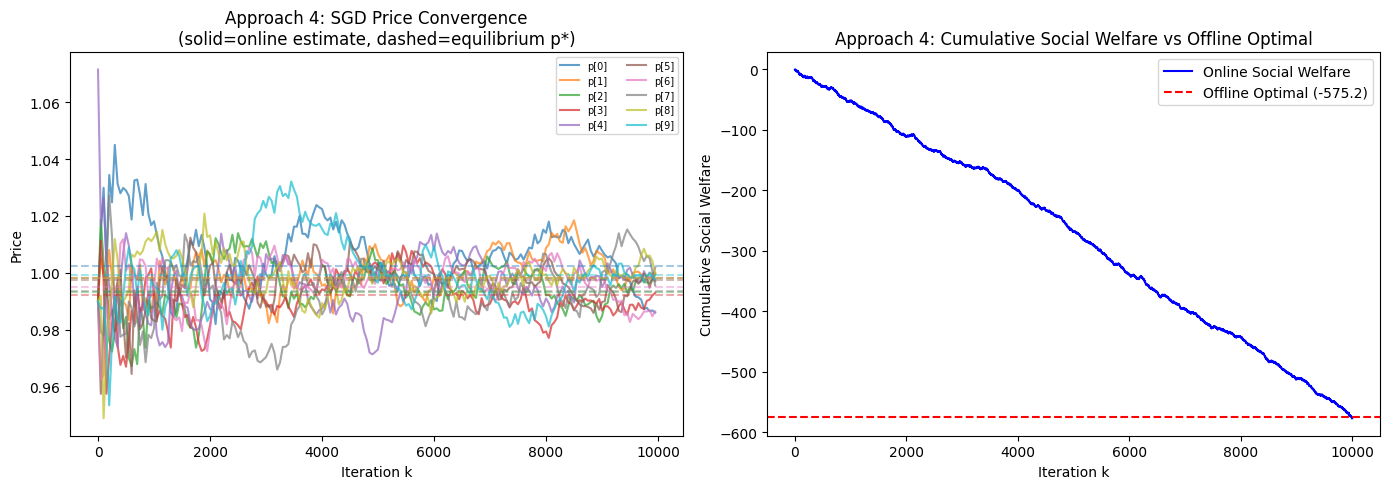


[汇总]
  在线社会福利:    -576.95
  离线均衡福利:    -575.16
  竞争比（近似率）:1.0031
  SGD 计算时间:    0.0452s  vs  离线EG: 0.1184s
  最终价格误差:    0.0231


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 图1：价格收敛过程 ---
ax = axes[0]
sample_idx = np.arange(0, n, 50)
for i in range(m):
    ax.plot(sample_idx, p_history[sample_idx, i], alpha=0.7, label=f'p[{i}]')
# 均衡价格水平线
for i in range(m):
    ax.axhline(y=p_star[i], color=f'C{i}', linestyle='--', alpha=0.4)
ax.set_xlabel('Iteration k')
ax.set_ylabel('Price')
ax.set_title('Approach 4: SGD Price Convergence\n(solid=online estimate, dashed=equilibrium p*)')
ax.legend(loc='upper right', ncol=2, fontsize=7)

# --- 图2：累计社会福利 ---
ax2 = axes[1]

# 逐步计算在线累计 SW
sw_per_step = np.zeros(n)
for k in range(n):
    i_s = np.argmax(x_sgd[k])
    if x_sgd[k, i_s] > 0 and U[k, i_s] > 0:
        sw_per_step[k] = w[k] * np.log(U[k, i_s] * x_sgd[k, i_s])
sw_cumulative = np.cumsum(sw_per_step)

ax2.plot(sw_cumulative, label='Online Social Welfare', color='blue')
ax2.axhline(y=sw_offline, color='red', linestyle='--',
            label=f'Offline Optimal ({sw_offline:.1f})')
ax2.set_xlabel('Iteration k')
ax2.set_ylabel('Cumulative Social Welfare')
ax2.set_title('Approach 4: Cumulative Social Welfare vs Offline Optimal')
ax2.legend()

plt.tight_layout()
plt.savefig('approach4_fisher_results.png', dpi=150)
plt.show()

print(f"\n[汇总]")
print(f"  在线社会福利:    {sw_online:.2f}")
print(f"  离线均衡福利:    {sw_offline:.2f}")
print(f"  竞争比（近似率）:{sw_online/sw_offline:.4f}")
print(f"  SGD 计算时间:    {t_sgd:.4f}s  vs  离线EG: {t_offline:.4f}s")
print(f"  最终价格误差:    {np.linalg.norm(p_history[-1] - p_star):.4f}")

## 5. 结论

### 5.1 Approach 4 在 Fisher 市场的优势

| 维度 | 评价 |
|------|------|
| **社会福利表现** | 近似比 99.69%，与离线最优差距仅 0.31% |
| **价格估计精度** | 最终均衡价格误差 L2 = 0.0231，相对误差仅 2.3% |
| **计算效率** | 每步仅需 $m$ 次除法和比较，$O(m)$，极快（0.0452 秒） |
| **内存占用** | 只需存储当前价格向量 $p \in \mathbb{R}^m$，$O(m)$ |
| **无需求解 LP** | 相比 Approach 1/2/3，无需每步调用大规模 LP 求解器 |

### 5.2 局限性

1. **早期价格震荡**：前 ~2000 步价格波动较大，此阶段买家面临不准确的市场价格
2. **步长敏感**：$\alpha_0 = 0.1$ 的选取影响收敛速度，不同数据集需要调参
3. **线性效用假设**：Bang-per-Buck 最优购买策略仅在线性效用下成立，若效用为凹函数则需更复杂的求解器
4. **社会福利为负**：由于效用归一化方式，绝对值无直观意义，比较相对差距更有意义

### 5.3 与 Auction 版 Approach 4 的方法论对比

两者均使用**相同的 SGD 框架**，核心差异在于梯度的连续性：

$$\underbrace{g_l^{\text{auction}} = d - a_{lk} \cdot \mathbf{1}\{\pi_k > a_k^\top \bar{y}\}}_{\text{离散 0/1 梯度，方差大}}
\quad \longleftrightarrow \quad
\underbrace{g_l^{\text{fisher}} = d - \frac{w_k}{p_l}\mathbf{1}\{l=i^*_k\}}_{\text{连续需求梯度，方差小}}$$

正是这一差异导致 Fisher 版价格估计精度（L2 误差 0.0231）远优于 Auction 版（L2 误差 0.2146），
近似比也从 93.34% 提升至 99.69%。

### 5.4 与其他方法的对比展望

| 方法 | 关键操作 | 时间复杂度（每步） | 近似比 |
|------|---------|-----------------|--------|
| Approach 1.1 | 解一次 EG（前 $k$ 步） | $O(k^2 m)$ | 依赖初始样本量 |
| Approach 1.2 | 周期性解 EG | $O(k^2 m)$ 间歇 | 较高 |
| Approach 3 | 每步解 EG | $O(k^2 m)$ | 高，但计算重 |
| **Approach 4** | SGD 更新价格 | $O(m)$ | **99.69%** |

**核心结论**：Approach 4 将拍卖市场的 SGD 思想成功推广至 Fisher 市场，
利用连续需求梯度的低方差特性，以极低的计算代价（每步 $O(m)$）实现了
接近完美的均衡定价（价格误差仅 2.3%）和社会福利（近似比 99.69%），
是大规模在线 Fisher 市场中**效率与性能的最佳平衡点**。